# Regla climática desde el UTCI y calefacción/AC según ENCEVI

Hito **T3** de `PLAN-MEDI-ITER.md` (ADR-0006, opción K2). El componente
"confort térmico" del MEDI es *condicional al clima*: la falta de aire
acondicionado sólo es carencia donde hace calor y la de calefacción donde
hace frío. Aquí se define ese "dónde" con el propio atlas:

- `h_calor`: horas/año promedio (años catalogados en el STAC `utci`) en
  niveles **≥ 7** (calor fuerte, muy fuerte, extremo; UTCI > 32 °C).
- `h_frio`: horas/año promedio en niveles **≤ 3** (frío moderado o peor;
  UTCI < 0 °C). Se evaluó también ≤ 4 (< 9 °C): el altiplano acumula miles
  de horas frescas sin que se use calefacción, así que no discrimina.
- `necesita_ac = h_calor ≥ H_CALOR`, `necesita_calef = h_frio ≥ H_FRIO`.

Los umbrales se eligen **maximizando la coincidencia con la evidencia
externa** y se documentan: para AC, las regiones climáticas de la ENCEVI
(1 cálida extrema y 3 tropical = necesitan; 2 templada = no); para
calefacción, los estados donde la ENCEVI observa ≥ 8 % de viviendas con
calefactor. Cada AGEB toma las horas de su celda (tabla puente); municipio y
estado se resuelven por la población de sus AGEB (mayoría) y, para
municipios sin AGEB urbana, por la celda de su centroide.

Además se estiman con `factor_sem` las tasas ENCEVI 2018 por región y
estado: `p_sin_calef` (único origen posible de la calefacción) y
`p_sin_ac_encevi` (para contrastar con el Censo).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

from atlas import stac

ROOT = Path("..").resolve()
ENCEVI = ROOT / "data" / "raw" / "INEGI" / "encevi_2018"
OUT_DIR = ROOT / "data" / "derived" / "INEGI" / "2020"
NIVEL_CALOR_MIN, NIVEL_FRIO_MAX = 7, 3
NIVEL_FRIO_ALT = 4                 # alternativa evaluada (< 9 °C)
UMBRAL_CALEF_ESTADO = 8.0      # % viviendas con calefactor (ENCEVI) para considerar que el estado "necesita" calefacción

# Regiones ENCEVI 2018 (se leen de vivienda.csv; aquí sólo la etiqueta)
REGION_NOMBRE = {"1": "cálida extrema", "2": "templada", "3": "tropical"}

## 1. Horas de calor y de frío por celda (promedio de los años del STAC)

In [2]:
anios = stac.available_years()
campos = []
for y in anios:
    lv = stac.open_levels(y)
    h = lv["hours"]
    calor = h.sel(level=slice(NIVEL_CALOR_MIN, None)).sum("level")
    frio = h.sel(level=slice(None, NIVEL_FRIO_MAX)).sum("level")
    frio_alt = h.sel(level=slice(None, NIVEL_FRIO_ALT)).sum("level")
    campos.append(xr.Dataset({"h_calor": calor, "h_frio": frio, "h_frio_alt": frio_alt}).assign_coords(year=y))
clima = xr.concat(xr.align(*campos, join="inner"), dim="year").mean("year")
celdas = clima.to_dataframe().reset_index()
celdas["lat_c"] = celdas["lat"].round(2)
celdas["lon_c"] = celdas["lon"].round(2)
print("años:", anios, "| celdas:", len(celdas))
print(celdas[["h_calor", "h_frio", "h_frio_alt"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(0).T)

años: [2022, 2023] | celdas: 10087
              count    mean     std  min    25%    50%     75%     90%     max
h_calor     10087.0  1016.0   737.0  0.0  392.0  910.0  1440.0  2106.0  3668.0
h_frio      10087.0   280.0   468.0  0.0    0.0    6.0   419.0   936.0  3106.0
h_frio_alt  10087.0  1008.0  1103.0  0.0    2.0  526.0  1871.0  2746.0  4898.0


## 2. Horas por AGEB (tabla puente), municipio y estado

In [3]:
grid = stac.read_medi("grid", 2020, columns=["cvegeo", "lat_c", "lon_c", "pobtot"])
HCOLS = ["h_calor", "h_frio", "h_frio_alt"]
filas = grid.merge(celdas[["lat_c", "lon_c"] + HCOLS], on=["lat_c", "lon_c"], how="left")
assert filas["h_calor"].notna().all(), "unidad sin celda UTCI"
# Una AGEB urbana es una fila; una AGEB rural son varias localidades (puntos):
# se promedian sus celdas ponderando por población.
ageb = filas.groupby("cvegeo").apply(lambda g: pd.Series({
    **{c: np.average(g[c], weights=np.maximum(g["pobtot"], 1)) for c in HCOLS},
    "pobtot": g["pobtot"].sum(),
}), include_groups=False).reset_index()
ageb["cve_mun"] = ageb["cvegeo"].str[:5]
ageb["cve_ent"] = ageb["cvegeo"].str[:2]
print("AGEB con horas:", len(ageb), "| filas de la tabla puente:", len(filas))

# Municipios: promedio ponderado por población de sus AGEB; sin AGEB → celda del centroide municipal
mun_geo = stac.read_medi("mun", 2020, columns=["cvegeo", "cve_ent", "pobtot", "cent_lon", "cent_lat"]).drop(columns="geometry")
w = ageb.groupby("cve_mun").apply(lambda g: pd.Series({
    c: np.average(g[c], weights=np.maximum(g["pobtot"], 1)) for c in HCOLS
}), include_groups=False)
mun = mun_geo.merge(w, left_on="cvegeo", right_index=True, how="left")
sin = mun["h_calor"].isna()
res = 0.25
mun.loc[sin, "lat_c"] = (np.round(mun.loc[sin, "cent_lat"] / res) * res).round(2)
mun.loc[sin, "lon_c"] = (np.round(mun.loc[sin, "cent_lon"] / res) * res).round(2)
fill = mun.loc[sin, ["lat_c", "lon_c"]].merge(celdas[["lat_c", "lon_c"] + HCOLS], on=["lat_c", "lon_c"], how="left")
mun.loc[sin, HCOLS] = fill[HCOLS].values
print("municipios sin AGEB urbana resueltos por centroide:", int(sin.sum()), "| sin celda:", int(mun['h_calor'].isna().sum()))
assert mun["h_calor"].notna().all()

ent = mun.groupby("cve_ent").apply(lambda g: pd.Series({
    **{c: np.average(g[c], weights=g["pobtot"]) for c in HCOLS},
    "pobtot": g["pobtot"].sum(),
}), include_groups=False)

AGEB con horas: 79181 | filas de la tabla puente: 248503


municipios sin AGEB urbana resueltos por centroide: 0 | sin celda: 0


## 3. ENCEVI 2018: regiones, calefacción y AC por estado y región

In [4]:
def rd(f):
    return pd.read_csv(ENCEVI / f, dtype=str, encoding="latin-1").rename(columns=lambda c: c.replace("ï»¿", ""))


ev = rd("vivienda.csv").merge(rd("encevi.csv")[["folio", "uso_aire", "uso_calef"]], on="folio")
ev["w"] = pd.to_numeric(ev["factor_sem"])
ev["cve_ent"] = ev["entidad"].str.zfill(2)
ev["sin_calef"] = np.where(ev["uso_calef"] == "2", 1.0, np.where(ev["uso_calef"] == "1", 0.0, np.nan))
ev["sin_ac"] = np.where(ev["uso_aire"] == "2", 1.0, np.where(ev["uso_aire"] == "1", 0.0, np.nan))


def tasa(df, by, col):
    d = df[df[col].notna()]
    return d.groupby(by).apply(lambda g: np.average(g[col], weights=g["w"]) * 100, include_groups=False)


region_ent = ev.groupby("cve_ent")["region"].agg(lambda s: s.mode().iat[0])
assert (ev.groupby("cve_ent")["region"].nunique() == 1).all(), "un estado en más de una región"
encevi_ent = pd.DataFrame({
    "region_encevi": region_ent,
    "p_sin_calef_ent": tasa(ev, "cve_ent", "sin_calef"),
    "p_sin_ac_encevi_ent": tasa(ev, "cve_ent", "sin_ac"),
    "n_encevi": ev.groupby("cve_ent").size(),
})
encevi_reg = pd.DataFrame({
    "p_sin_calef_reg": tasa(ev, "region", "sin_calef"),
    "p_sin_ac_encevi_reg": tasa(ev, "region", "sin_ac"),
})
encevi_ent = encevi_ent.join(encevi_reg, on="region_encevi")
encevi_ent["region_nombre"] = encevi_ent["region_encevi"].map(REGION_NOMBRE)
print(encevi_reg.round(1))
print(encevi_ent.sort_values("p_sin_calef_ent").head(8).round(1).to_string())

        p_sin_calef_reg  p_sin_ac_encevi_reg
region                                      
1                  79.6                 51.9
2                  97.5                 98.7
3                  99.5                 87.6
        region_encevi  p_sin_calef_ent  p_sin_ac_encevi_ent  n_encevi  p_sin_calef_reg  p_sin_ac_encevi_reg   region_nombre
cve_ent                                                                                                                    
08                  1             43.4                 51.2       874             79.6                 51.9  cálida extrema
05                  1             71.0                 62.9       863             79.6                 51.9  cálida extrema
19                  1             74.1                 56.1       910             79.6                 51.9  cálida extrema
28                  1             82.0                 52.8       902             79.6                 51.9  cálida extrema
26                  1          

## 4. Umbrales: los que mejor reproducen la evidencia externa (a nivel estado)
La referencia externa es **estatal** (región ENCEVI; % de viviendas con
calefactor por estado), así que el umbral se ajusta con los 32 estados
ponderados por población y después se aplica a municipios y AGEB. La
coincidencia municipal se reporta sólo como información: dentro de un
estado "templado" hay municipios costeros calurosos, y eso es justamente lo
que la regla por celda añade sobre la región.

In [5]:
ent = ent.join(encevi_ent[["region_encevi", "p_sin_calef_ent"]])
ent["ref_ac"] = ent["region_encevi"].isin(["1", "3"])
ent["ref_calef"] = (100 - ent["p_sin_calef_ent"]) >= UMBRAL_CALEF_ESTADO


def mejor_umbral(h: pd.Series, ref: pd.Series, pesos: pd.Series) -> tuple[float, float]:
    candidatos = np.unique(np.round(np.quantile(h, np.linspace(0.02, 0.98, 97)), 0))
    mejor = max(((np.average((h >= u) == ref, weights=pesos), u) for u in candidatos), key=lambda t: (t[0], -t[1]))
    return float(mejor[1]), float(mejor[0])


H_CALOR, acc_calor = mejor_umbral(ent["h_calor"], ent["ref_ac"], ent["pobtot"])
H_FRIO, acc_frio = mejor_umbral(ent["h_frio"], ent["ref_calef"], ent["pobtot"])
H_FRIO_ALT, acc_frio_alt = mejor_umbral(ent["h_frio_alt"], ent["ref_calef"], ent["pobtot"])
print(f"H_CALOR = {H_CALOR:.0f} h/año en niveles ≥ {NIVEL_CALOR_MIN} (UTCI > 32 °C) → coincidencia estatal con regiones ENCEVI: {acc_calor:.1%}")
print(f"H_FRIO  = {H_FRIO:.0f} h/año en niveles ≤ {NIVEL_FRIO_MAX} (UTCI < 0 °C)  → coincidencia con estados ≥{UMBRAL_CALEF_ESTADO:.0f}% calefactor: {acc_frio:.1%}")
print(f"   alternativa niveles ≤ {NIVEL_FRIO_ALT} (UTCI < 9 °C): umbral {H_FRIO_ALT:.0f} h, coincidencia {acc_frio_alt:.1%} (descartada si es menor)")
assert acc_calor >= 0.85, "la regla de calor no reproduce las regiones ENCEVI"
if acc_frio_alt > acc_frio:
    print("   → la alternativa < 9 °C discrimina mejor; se adopta")
    NIVEL_FRIO_MAX, H_FRIO, acc_frio = NIVEL_FRIO_ALT, H_FRIO_ALT, acc_frio_alt
    for df in (ageb, mun, ent):
        df["h_frio"] = df["h_frio_alt"]

for df in (ageb, mun, ent):
    df["necesita_ac"] = df["h_calor"] >= H_CALOR
    df["necesita_calef"] = df["h_frio"] >= H_FRIO
mun = mun.join(ent[["ref_ac", "ref_calef"]], on="cve_ent")
print(f"coincidencia municipal (informativa, ref. estatal heredada): AC {np.average(mun['necesita_ac'] == mun['ref_ac'], weights=mun['pobtot']):.1%}, "
      f"calefacción {np.average(mun['necesita_calef'] == mun['ref_calef'], weights=mun['pobtot']):.1%}")
print("\nestados: horas, necesidad y referencia")
tabla_ent = ent.assign(region=ent["region_encevi"].map(REGION_NOMBRE), p_calef=(100 - ent["p_sin_calef_ent"]))
print(tabla_ent[["region", "h_calor", "necesita_ac", "ref_ac", "h_frio", "necesita_calef", "ref_calef", "p_calef"]].round(0).sort_values("h_calor").to_string())
print("\nAGEB que necesitan AC:", f"{ageb['necesita_ac'].mean():.1%}", "| calefacción:", f"{ageb['necesita_calef'].mean():.1%}",
      "| ambas:", f"{(ageb['necesita_ac'] & ageb['necesita_calef']).mean():.1%}", "| ninguna:", f"{(~ageb['necesita_ac'] & ~ageb['necesita_calef']).mean():.1%}")

H_CALOR = 902 h/año en niveles ≥ 7 (UTCI > 32 °C) → coincidencia estatal con regiones ENCEVI: 95.4%
H_FRIO  = 626 h/año en niveles ≤ 3 (UTCI < 0 °C)  → coincidencia con estados ≥8% calefactor: 87.8%
   alternativa niveles ≤ 4 (UTCI < 9 °C): umbral 2849 h, coincidencia 82.1% (descartada si es menor)
coincidencia municipal (informativa, ref. estatal heredada): AC 80.6%, calefacción 86.0%

estados: horas, necesidad y referencia
                 region  h_calor  necesita_ac  ref_ac  h_frio  necesita_calef  ref_calef  p_calef
cve_ent                                                                                          
29             templada      2.0        False   False   232.0           False      False      2.0
09             templada     27.0        False   False   311.0           False      False      5.0
15             templada     85.0        False   False   206.0           False      False      2.0
22             templada    211.0        False   False   116.0           False    

## 5. Escritura
`clima_*_2020.parquet` con horas y necesidades por nivel; `encevi_ent_2018.parquet`
con las tasas por estado (y las de su región) para heredar la calefacción.

In [6]:
cols = ["h_calor", "h_frio", "necesita_ac", "necesita_calef"]
ageb[["cvegeo"] + cols].to_parquet(OUT_DIR / "clima_ageb_2020.parquet", index=False)
mun[["cvegeo"] + cols].to_parquet(OUT_DIR / "clima_mun_2020.parquet", index=False)
ent.reset_index()[["cve_ent"] + cols].to_parquet(OUT_DIR / "clima_ent_2020.parquet", index=False)
encevi_ent.reset_index().to_parquet(OUT_DIR / "encevi_ent_2018.parquet", index=False)
pd.DataFrame([{
    "anios_utci": ",".join(map(str, anios)), "nivel_calor_min": NIVEL_CALOR_MIN, "nivel_frio_max": NIVEL_FRIO_MAX,
    "H_CALOR": H_CALOR, "H_FRIO": H_FRIO, "coincidencia_ac": acc_calor, "coincidencia_calef": acc_frio,
    "umbral_calef_estado_pct": UMBRAL_CALEF_ESTADO,
}]).to_parquet(OUT_DIR / "clima_umbrales_2020.parquet", index=False)
for n in ["clima_ageb_2020", "clima_mun_2020", "clima_ent_2020", "encevi_ent_2018", "clima_umbrales_2020"]:
    p = OUT_DIR / f"{n}.parquet"
    print("escrito", p.name, pd.read_parquet(p).shape)

escrito clima_ageb_2020.parquet (79181, 5)
escrito clima_mun_2020.parquet (2469, 5)
escrito clima_ent_2020.parquet (32, 5)
escrito encevi_ent_2018.parquet (32, 8)
escrito clima_umbrales_2020.parquet (1, 8)


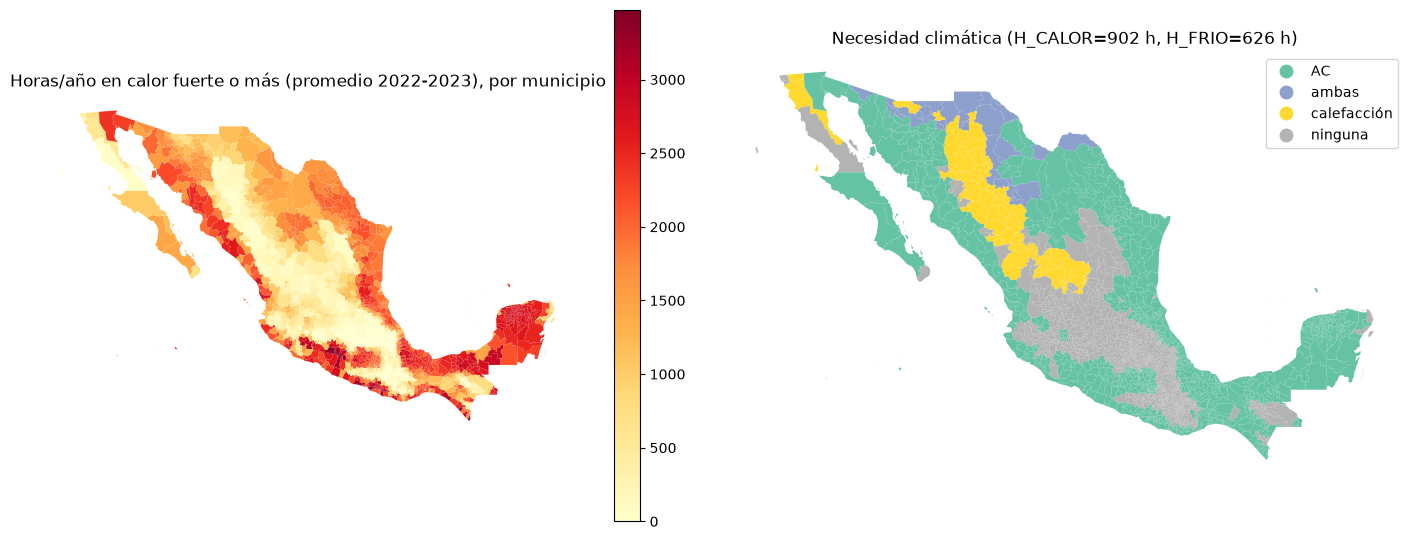

In [7]:
import matplotlib.pyplot as plt

g = stac.read_medi("mun", 2020, columns=["cvegeo"]).merge(mun[["cvegeo", "h_calor", "necesita_ac", "necesita_calef"]], on="cvegeo")
fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
g.plot(column="h_calor", ax=axs[0], cmap="YlOrRd", legend=True, edgecolor="none")
axs[0].set_title(f"Horas/año en calor fuerte o más (promedio {'-'.join(map(str, anios))}), por municipio")
g.assign(cat=np.select([g.necesita_ac & g.necesita_calef, g.necesita_ac, g.necesita_calef], ["ambas", "AC", "calefacción"], "ninguna")) \
 .plot(column="cat", ax=axs[1], categorical=True, legend=True, cmap="Set2", edgecolor="none")
axs[1].set_title(f"Necesidad climática (H_CALOR={H_CALOR:.0f} h, H_FRIO={H_FRIO:.0f} h)")
for ax in axs:
    ax.set_axis_off()
plt.tight_layout()